## Creating the Notebook and Importing in Data from the Group Github

In [1]:
#Import Initial libraries

#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile



In [2]:
#Run code provided by Chance for consitent notebooks within the group

#File path to the zipped datafile
zip_path = '../../Data/Processed/Data_Compressed.zip'

#List of filenames to read from the zip file
filenames = [
    'Data_Compressed/all_normalized_features.csv',
    'Data_Compressed/kdd_all_normalized_features.csv',
    'Data_Compressed/kdd_expanded_all_scaled.csv',
    'Data_Compressed/kdd_merged_normalized_all.csv'
]

#Corresponding names for the DataFrames
df_names = [
    'xuetangx_df',
    'kdd_df',
    'kdd_expanded_df',
    'kdd_merged_df'
]

#Create an empty dictionary to store the DataFrames
dataframes = {}

#Open the zip file
z = zipfile.ZipFile(zip_path, 'r')

#Loop through the filenames and read them into DataFrames
for i, file in enumerate(filenames):
    print(f"Reading file: {file} from {zip_path}")
    
    #Read each CSV file directly from the zip
    f = z.open(file)
    dataframes[df_names[i]] = pd.read_csv(f)
    f.close()
    
    print(f"{df_names[i]} loaded with shape: {dataframes[df_names[i]].shape}\n")

#Close the zip file after reading
z.close()

#Assign individual DataFrames to variables
xuetangx_df = dataframes['xuetangx_df']
kdd_df = dataframes['kdd_df']
kdd_expanded_df = dataframes['kdd_expanded_df']
kdd_merged_df = dataframes['kdd_merged_df']

Reading file: Data_Compressed/all_normalized_features.csv from ../../Data/Processed/Data_Compressed.zip
xuetangx_df loaded with shape: (225642, 30)

Reading file: Data_Compressed/kdd_all_normalized_features.csv from ../../Data/Processed/Data_Compressed.zip
kdd_df loaded with shape: (200904, 17)

Reading file: Data_Compressed/kdd_expanded_all_scaled.csv from ../../Data/Processed/Data_Compressed.zip
kdd_expanded_df loaded with shape: (120542, 142)

Reading file: Data_Compressed/kdd_merged_normalized_all.csv from ../../Data/Processed/Data_Compressed.zip
kdd_merged_df loaded with shape: (120542, 158)



## Section 2: Data Review and Prep
-View info and head data for kdd_expanded to ensure proper importation
  - This is the data frame with the larger feature set (140 features) generated by Peng and Aggarwal
- Import additional libraries 
- Create the X and y dataset to mirror the variables used in the paper
- Split the data into training and testing with an 80/20 ratio

In [3]:
# Code Block 3
#View the basic info for the data set before starting toensure proper importation

kdd_expanded_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120542 entries, 0 to 120541
Data columns (total 142 columns):
 #    Column                             Dtype  
---   ------                             -----  
 0    Unnamed: 0                         int64  
 1    enrollment_id                      int64  
 2    truth                              int64  
 3    avg_chapter_delays                 float64
 4    server_discussion_percent          int64  
 5    act_cnt_weekDay_01                 float64
 6    browser_html_percent               int64  
 7    parallel_enrollments               float64
 8    browser_dictation                  int64  
 9    act_cnt_day_00                     int64  
 10   act_cnt_day_01                     float64
 11   act_cnt_day_02                     float64
 12   act_cnt_day_03                     float64
 13   act_cnt_day_04                     float64
 14   act_cnt_day_05                     float64
 15   act_cnt_day_06                     float64
 16   

In [4]:
## Code Block 4
# View header information for Kdd-expanded
kdd_expanded_df.head()

,Unnamed: 0,enrollment_id,truth,avg_chapter_delays,server_discussion_percent,act_cnt_weekDay_01,browser_html_percent,parallel_enrollments,browser_dictation,act_cnt_day_00,...,server_course_percent,browser_course_info_percent,browser_course,browser_vertical_percent,sessions_in_week_1,sessions_in_week_0,sessions_in_week_3,sessions_in_week_2,sessions_in_week_4,browser_about
0,0,1,0,0.401837,0,0.317621,0,3.960922,0,0,...,0,0,0,0,2.076406,-0.029110,1.685275,2.636167,2.141673,0
1,1,3,0,0.460054,0,-0.005913,0,-0.449933,0,0,...,0,0,0,0,0.565552,0.466433,0.126527,0.087058,0.928388,0
2,2,4,0,0.866122,0,-0.094149,0,0.652780,0,0,...,0,0,0,0,1.572788,1.457518,-0.393056,2.126345,-0.284897,0
3,3,5,0,0.429975,0,1.964698,0,-0.449933,0,0,...,0,0,0,0,7.616205,0.466433,6.361519,0.087058,4.568243,0
4,4,6,0,-0.255399,0,-0.123561,0,-0.449933,0,0,...,0,0,0,0,-0.441684,-0.524652,0.126527,-0.422764,2.141673,0


### Importing Additional Libraries for modeling

In [5]:
# Code Block 5
# Import Models based on the Jupyter Notebook on Github related to the paper and modeling experiments
## https://github.com/rambasnet/PredictingMOOCDropouts/blob/master/KDD_experiments.ipynb

# Additional Scikit-Learn imports
from sklearn.model_selection import StratifiedKFold

# Scikit-Learn's ML models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# Had assistance from the Anaconda AI Assistant due to needing to pip install the library first
import xgboost as xgb
from xgboost import XGBClassifier

#Importing additional pieces of sklearn that may be needed 
## These imports are based on modeling in DATA6320
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [6]:
#Code Block 6
# Create the X and y data sets
## 'truth' is the variable for dropout rate as seen in the original code from the research
y= kdd_expanded_df['truth']
display(y.value_counts())
display(round(y.value_counts(normalize=True),3))

truth
1    95581
0    24961
Name: count, dtype: int64

truth
1    0.793
0    0.207
Name: proportion, dtype: float64

In [7]:
#Code Block 7
#Create the X data set with by dropping columns that do not belong in the model BurgStatus

X = kdd_expanded_df.drop (['truth','Unnamed: 0','enrollment_id'], axis=1)
X.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120542 entries, 0 to 120541
Data columns (total 139 columns):
 #    Column                             Dtype  
---   ------                             -----  
 0    avg_chapter_delays                 float64
 1    server_discussion_percent          int64  
 2    act_cnt_weekDay_01                 float64
 3    browser_html_percent               int64  
 4    parallel_enrollments               float64
 5    browser_dictation                  int64  
 6    act_cnt_day_00                     int64  
 7    act_cnt_day_01                     float64
 8    act_cnt_day_02                     float64
 9    act_cnt_day_03                     float64
 10   act_cnt_day_04                     float64
 11   act_cnt_day_05                     float64
 12   act_cnt_day_06                     float64
 13   act_cnt_day_07                     float64
 14   act_cnt_day_08                     float64
 15   act_cnt_day_09                     float64
 16   

In [8]:
#Code Block 8
#Split the data set into an 80/20 random split for training and testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 100)



In [9]:
#code Block 9
# Define function for short train test to condense the output 
## Technique from Data 6320

def shorttraintest(vartrain, vartest, y_train, y_test, model):

    #Fit the model
    model.fit(vartrain, y_train)

    #Predict with the model
    model_pred = model.predict(vartest)
    model_prob = model.predict_proba(vartest)


    print('Confusion Matrix:')
    print(confusion_matrix(y_test, model_pred))
    print("")

    #Assess with the model
    score = model.score(vartest, y_test)
    score_format = 'Accuracy Score: {0:.4f}'.format(score)
    print(score_format)

    recall = recall_score(y_test, model_pred)
    recall_format = 'Recall Score: {0:.4f}'.format(recall)
    print(recall_format)
    
    precision = precision_score(y_test, model_pred)
    precision_format = 'Precision Score: {0:.4f}'.format(precision)
    print(precision_format)
    
    # calculate roc curve
    y_pred_prob = model.predict_proba(vartest)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    roc_auc_format = 'ROC AUC Score: {0:.4f}'.format(roc_auc)
    print(roc_auc_format)
    print('')

## Section 3: Perform Modeling with the same 9 Machine Learning Models used in the paper
    - Check reproducibility by ability/ease of modeling and accuracy score results

### Model 1: Random Forest (RF)

In [10]:
#Code Block 10
# Running the Random Forest Model

vartrain = X_train
vartest = X_test
model = RandomForestClassifier()
shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2905  2096]
 [  851 18257]]

Accuracy Score: 0.8778
Recall Score: 0.9555
Precision Score: 0.8970
ROC AUC Score: 0.8765



In [11]:
#Code Block 11
# Conducting 5 fold Cross Validation for Random Forest

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
cv_model = RandomForestClassifier() 

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

Cross-validation scores: [0.87421579 0.87120859 0.8788303  0.87483148 0.87524629]
Mean CV accuracy: 0.8749
Standard deviation: 0.0024
CV Accuracy Scores:
[0.87421579 0.87120859 0.8788303  0.87483148 0.87524629]



### Model 2: XGBoost (XGB)

In [12]:
#Code Block 12
# Running the XGB Model
vartrain = X_train
vartest = X_test
model =  XGBClassifier()

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2854  2147]
 [  856 18252]]

Accuracy Score: 0.8754
Recall Score: 0.9552
Precision Score: 0.8947
ROC AUC Score: 0.8812



In [13]:
#Code Block 13
# Conducting 5 fold Cross Validation for XGB

cv_model = XGBClassifier()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')


Cross-validation scores: [0.87281589 0.87006792 0.87530461 0.87695738 0.87410557]
Mean CV accuracy: 0.8739
Standard deviation: 0.0023
CV Accuracy Scores:
[0.87281589 0.87006792 0.87530461 0.87695738 0.87410557]



### Model 3: AdaBoost Classifier (AB)

In [14]:
#Code Block 14
# Running the AdaBoost Classifier
vartrain = X_train
vartest = X_test
model = AdaBoostClassifier()

shorttraintest(vartrain, vartest, y_train, y_test, model)

c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Confusion Matrix:
[[ 2818  2183]
 [  754 18354]]

Accuracy Score: 0.8782
Recall Score: 0.9605
Precision Score: 0.8937
ROC AUC Score: 0.8803



In [15]:
#Code Block 16
# Running 5 fold Cross Validation for AB
cv_model = AdaBoostClassifier()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\aut

Cross-validation scores: [0.87514906 0.87395655 0.87810442 0.87623146 0.87685368]
Mean CV accuracy: 0.8761
Standard deviation: 0.0014
CV Accuracy Scores:
[0.87514906 0.87395655 0.87810442 0.87623146 0.87685368]



### Model 4: Decision Tree (DT)

In [16]:
#Code Block 17
# Running the DecisionTree Classifier
vartrain = X_train
vartest = X_test
model = DecisionTreeClassifier()

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2800  2201]
 [ 2397 16711]]

Accuracy Score: 0.8093
Recall Score: 0.8746
Precision Score: 0.8836
ROC AUC Score: 0.7175



In [17]:
#Code Block 18
#Running 5 fold Cross Validation for DT

cv_model = DecisionTreeClassifier()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

Cross-validation scores: [0.80142065 0.8062944  0.80821279 0.81157316 0.80332884]
Mean CV accuracy: 0.8062
Standard deviation: 0.0036
CV Accuracy Scores:
[0.80142065 0.8062944  0.80821279 0.81157316 0.80332884]



### Model 5: K-Neighbors (kNN)

In [18]:
#Code Block 19
# Running the K-Neighbors Model
vartrain = X_train
vartest = X_test
model = KNeighborsClassifier()
shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2249  2752]
 [  710 18398]]

Accuracy Score: 0.8564
Recall Score: 0.9628
Precision Score: 0.8699
ROC AUC Score: 0.8019



In [19]:
#Code Block 20
# Running 5 fold Cross Validation for kNN

cv_model =  KNeighborsClassifier()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

Cross-validation scores: [0.85243947 0.85218023 0.85243947 0.85372809 0.85367624]
Mean CV accuracy: 0.8529
Standard deviation: 0.0007
CV Accuracy Scores:
[0.85243947 0.85218023 0.85243947 0.85372809 0.85367624]



### Model 6: Logistic Regression (LR)

In [20]:
#Code Block 21
# Running 5 fold Cross Validation LR
vartrain = X_train
vartest = X_test
model = LogisticRegression()

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2585  2416]
 [  655 18453]]

Accuracy Score: 0.8726
Recall Score: 0.9657
Precision Score: 0.8842
ROC AUC Score: 0.8783



In [21]:
##Code Block 22
# Running 5 fold Cross Validation for LR

cv_model =  LogisticRegression()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

Cross-validation scores: [0.87183077 0.86980868 0.87597864 0.8732241  0.87296484]
Mean CV accuracy: 0.8728
Standard deviation: 0.0020
CV Accuracy Scores:
[0.87183077 0.86980868 0.87597864 0.8732241  0.87296484]



### Model 7: Linear Discriminate Analysis (LDA)

In [22]:
##Code Block 23
# Running the Model for LDA

vartrain = X_train
vartest = X_test
model =LinearDiscriminantAnalysis()

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2462  2539]
 [  593 18515]]

Accuracy Score: 0.8701
Recall Score: 0.9690
Precision Score: 0.8794
ROC AUC Score: 0.8726



In [23]:
##Code Block 24
# Running 5 fold Cross Validation for LDA

cv_model = LinearDiscriminantAnalysis()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

Cross-validation scores: [0.86830508 0.86664593 0.87364546 0.86959452 0.87016489]
Mean CV accuracy: 0.8697
Standard deviation: 0.0023
CV Accuracy Scores:
[0.86830508 0.86664593 0.87364546 0.86959452 0.87016489]



### Model 8: Naïve Bayes Classifier (NB)

In [24]:
##Code Block 25
# Running the Model for NB

vartrain = X_train
vartest = X_test
model = GaussianNB()

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[ 2763  2238]
 [ 1381 17727]]

Accuracy Score: 0.8499
Recall Score: 0.9277
Precision Score: 0.8879
ROC AUC Score: 0.7737



In [25]:
##Code Block 26
# Running 5 fold Cross Validation for NB

cv_model =  GaussianNB()

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train, cv=5, scoring='accuracy')

#Printing cv scores, mean and standard deviation for the model
##Co-pilot in VS Code assisted with code for printing mean and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print('CV Accuracy Scores:')
print(cv_scores)
print('')

Cross-validation scores: [0.84839529 0.8480842  0.85487634 0.8514985  0.85253552]
Mean CV accuracy: 0.8511
Standard deviation: 0.0026
CV Accuracy Scores:
[0.84839529 0.8480842  0.85487634 0.8514985  0.85253552]



### Model 9: Support Vector Machine (SVM)
- Running this model last due to computational power needed
- Sampling a subset of the data due to run time of the full data creating issues and timing out

In [26]:
##Code Block 27
# Entered Output Error code first received into Anaconda Assistant and am running the code provided by AI 

# Define input variables - using only 20% of training data to make computation manageable
# Sample both X_train and y_train with the same indices to maintain alignment
train_indices = X_train.sample(frac=0.2, random_state=42).index
vartrain = X_train.loc[train_indices]
y_train_sampled = y_train.loc[train_indices]  # Assuming y_train is a pandas Series/DataFrame

# Keep test data as is
vartest = X_test

# Initialize Support Vector Machine Classifier with probability=True
# This enables the predict_proba method that the shorttraintest function is trying to use
model = SVC(probability=True)

# Use the sampled training data with corresponding sampled labels
shorttraintest(vartrain, vartest, y_train_sampled, y_test, model)

Confusion Matrix:
[[ 2652  2349]
 [  798 18310]]

Accuracy Score: 0.8695
Recall Score: 0.9582
Precision Score: 0.8863
ROC AUC Score: 0.8296



In [27]:
##Code Block 28
# Cross-validation on the sampled data
# Created with the Anaconda Assistant to ensure(hopefully) proper execution of  cross validation with sample data

# Define the model for cross-validation
cv_model = SVC(probability=True)

# Perform k-fold cross-validation (using 5 folds)
cv_scores = cross_val_score(cv_model, vartrain, y_train_sampled, cv=5, scoring='accuracy')

# Print cross-validation results
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")


Cross-validation scores: [0.86132711 0.86625194 0.85973555 0.86569873 0.86492092]
Mean CV accuracy: 0.8636
Standard deviation: 0.0026


In [28]:
# Code Block 29
# Created data frame with the assistacnce of Co-pilot in VS Code

# Initialize a dictionary to store the results
cv_results = {
    "Model": [],
    "Mean Accuracy": [],
    "Standard Deviation": []
}

# Add results for each model
models = [
    ("Random Forest", RandomForestClassifier()),
    ("XGBoost", XGBClassifier()),
    ("AdaBoost", AdaBoostClassifier()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("K-Neighbors", KNeighborsClassifier()),
    ("Logistic Regression", LogisticRegression()),
    ("Linear Discriminant Analysis", LinearDiscriminantAnalysis()),
    ("Naïve Bayes", GaussianNB()),
    ("Support Vector Machine", SVC(probability=True))
]

# Perform cross-validation for each model
for model_name, model_instance in models:
    cv_scores = cross_val_score(model_instance, vartrain, y_train_sampled, cv=5, scoring='accuracy')
    cv_results["Model"].append(model_name)
    cv_results["Mean Accuracy"].append(cv_scores.mean())
    cv_results["Standard Deviation"].append(cv_scores.std())

# Create a DataFrame from the results
cv_results_df = pd.DataFrame(cv_results)

# Display the DataFrame
cv_results_df

c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\autum\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\aut

,Model,Mean Accuracy,Standard Deviation
0,Random Forest,0.870172,0.002706
1,XGBoost,0.865246,0.003936
2,AdaBoost,0.871053,0.004701
3,Decision Tree,0.803132,0.006656
4,K-Neighbors,0.845699,0.003498
5,Logistic Regression,0.867787,0.003485
6,Linear Discriminant Analysis,0.866283,0.004527
7,Naïve Bayes,0.847254,0.002221
8,Support Vector Machine,0.863587,0.002580


## Section 4: Results


- Results from the paper:

    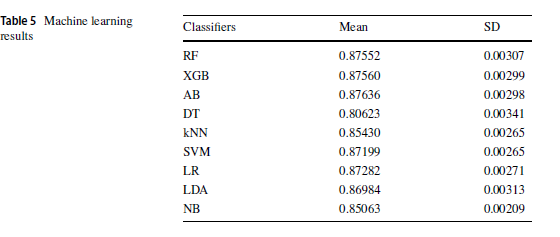

- As can be seen when comparing the scoring table created for the models in this experiment and table 5 from the paper as inserted here, the results fairly similar 
    - Approximate Difference in Mean Accuracy and Standard Devation(Original - Experimental): 
    -            Mean Acc       SD

        - RF:  
        -        .005,        .0004
        - XGB: 
         -       .010,       -.0009
        - AB:  
        -        .005,       -.0017
        - DT:   
        -        .003,       -.0032
        - kNN: 
        -        .009,       -.0008
        - LR:   
        -        .005,       -.0008
        - LDA:  
        -        .004,       -.0014
        - NB:   
        -        .003,       -.0001
        - SVM:  
        -        .008,       -.0001

- In the both the original prediction modeling and in the experimental reproduction modeling, AB performed the best with Mean Accuracy of 87.6% and 87.1%
   - My results resulted in similar, if not in exact, differences in both Mean Accuracy and Standard Deviation upon running all models a 2nd time. 
- Overall, I would state the data and the methodologies described in this paper allow for a highly reproduceable code